<a href="https://colab.research.google.com/github/scudilio/MBA---Deep-Learning/blob/main/Aula5_MBA_autoencoder_02_imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👕 Autoencoder para Imagens (Compressão e Denoising)

**Disciplina:** Deep Learning — MBA Data Science — FIAP  
**Professor:** Juliana
**Tema:** Autoencoders — Aplicação em Dados de Imagem

---

## 📋 Objetivo desta aula

1. Construir um autoencoder para **comprimir** imagens
2. Visualizar o **latent space** (representação comprimida)
3. Comparar imagens **originais vs reconstruídas**
4. Implementar um **Denoising Autoencoder** para remover ruído

---

## 🏢 Caso de Negócio: E-commerce de Moda

Um e-commerce recebe **milhões de fotos** de produtos.

**Problemas reais:**
- **Armazenamento caro** → precisa comprimir imagens sem perder qualidade
- **Fotos com ruído** → imagens de baixa qualidade dos sellers
- **Feature extraction** → criar representações compactas para sistema de recomendação

**Solução com Autoencoder:**
- Comprimir imagens de 784 pixels → 32 números (representação compacta)
- Limpar ruído de fotos automaticamente (Denoising Autoencoder)
- Usar o latent space como features para outros modelos

---

## 📊 Dataset: Fashion MNIST

Usaremos o **Fashion MNIST** — 70.000 imagens 28×28 de peças de roupa.
- 10 categorias: Camiseta, Calça, Suéter, Vestido, Casaco, Sandália, Camisa, Tênis, Bolsa, Bota
- Grayscale (0-255)
- Leve, rápido, sem necessidade de download externo


## 1. Imports e Configurações

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping

# Configurações
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('dark_background')

# Nomes das classes do Fashion MNIST
class_names = ['Camiseta', 'Calça', 'Suéter', 'Vestido', 'Casaco',
               'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota']

print(f"TensorFlow: {tf.__version__}")


TensorFlow: 2.19.0


## 2. Carregar e Preparar os Dados

### Pré-processamento de imagens para autoencoder:
1. **Normalizar** pixels de `[0, 255]` para `[0, 1]`
2. **Achatar** de `28×28` para vetor de `784` (para Dense layers)


In [2]:
# ═══════════════════════════════════════════════════════════
# Carregar Fashion MNIST
# ═══════════════════════════════════════════════════════════

(X_train_raw, y_train), (X_test_raw, y_test) = fashion_mnist.load_data()

print(f"Treino: {X_train_raw.shape} — {len(y_train)} labels")
print(f"Teste:  {X_test_raw.shape} — {len(y_test)} labels")
print(f"Pixel range: [{X_train_raw.min()}, {X_train_raw.max()}]")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Treino: (60000, 28, 28) — 60000 labels
Teste:  (10000, 28, 28) — 10000 labels
Pixel range: [0, 255]


In [3]:
# ═══════════════════════════════════════════════════════════
# Normalizar e achatar
# ═══════════════════════════════════════════════════════════

# Normalizar para [0, 1]
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32') / 255.0

# Achatar de (28, 28) para (784,) — input para Dense layers
X_train_flat = X_train.reshape(-1, 784)
X_test_flat  = X_test.reshape(-1, 784)

print(f"Shape treino: {X_train_flat.shape}")
print(f"Shape teste:  {X_test_flat.shape}")
print(f"Pixel range:  [{X_train_flat.min():.1f}, {X_train_flat.max():.1f}]")


Shape treino: (60000, 784)
Shape teste:  (10000, 784)
Pixel range:  [0.0, 1.0]


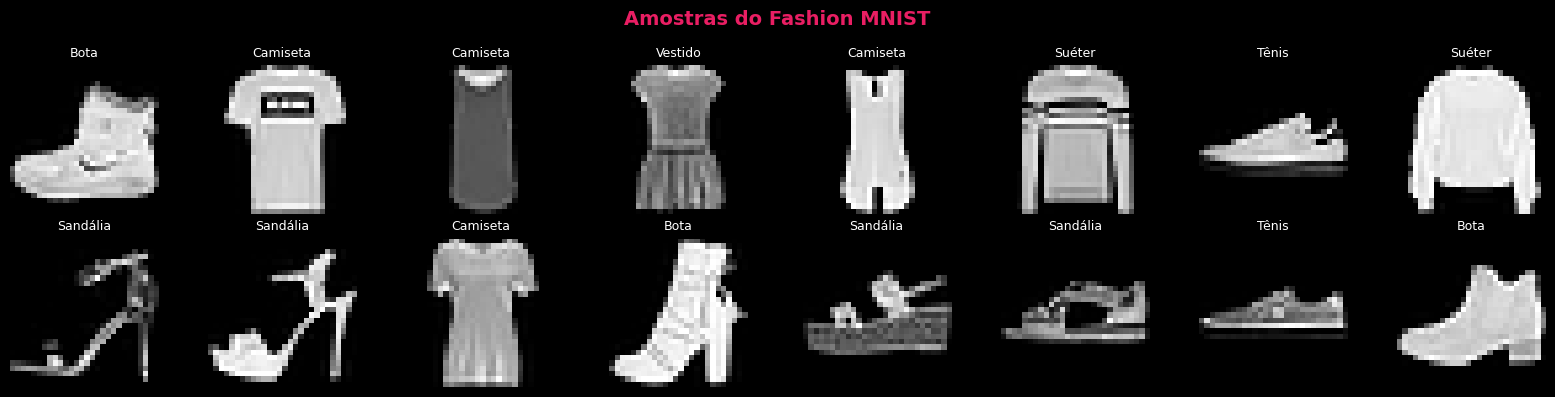

In [4]:
# ═══════════════════════════════════════════════════════════
# Visualizar algumas amostras
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(class_names[y_train[i]], fontsize=9)
    ax.axis('off')

plt.suptitle('Amostras do Fashion MNIST', fontsize=14, fontweight='bold', color='#E91E63')
plt.tight_layout()
plt.show()


## 3. Autoencoder para Compressão de Imagens

### Arquitetura:

```
Input (784 pixels)
    ↓
Dense(256, relu)     ← Encoder
    ↓
Dense(64, relu)      ← Encoder
    ↓
Dense(32, relu)      ← Latent Space (gargalo) — comprimimos 784 → 32 (96% de redução!)
    ↓
Dense(64, relu)      ← Decoder
    ↓
Dense(256, relu)     ← Decoder
    ↓
Output (784, sigmoid) ← Imagem reconstruída
```

> **Taxa de compressão:** 784 / 32 = **24.5×** — armazenamos apenas 4% da informação original!


In [5]:
# ═══════════════════════════════════════════════════════════
# Construir o Autoencoder para Imagens
# ═══════════════════════════════════════════════════════════

input_dim = 784          # 28 x 28 pixels
latent_dim = 32          # gargalo: comprime para 32 valores

# Camada de entrada
input_img = Input(shape=(input_dim,))

# ENCODER: 784 → 256 → 64 → 32
encoded = Dense(256, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
latent = Dense(latent_dim, activation='relu')(encoded)    # bottleneck

# DECODER: 32 → 64 → 256 → 784
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(256, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)  # sigmoid para [0,1]

# Modelo completo
autoencoder = Model(inputs=input_img, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Modelo do Encoder separado (para extrair features depois)
encoder = Model(inputs=input_img, outputs=latent)

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 439,728 (1.68 MB)

 Trainable params: 439,728 (1.68 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Treinamento

In [6]:
# ═══════════════════════════════════════════════════════════
# Treinar o autoencoder
# ═══════════════════════════════════════════════════════════

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train_flat,         # entrada
    X_train_flat,         # saída = mesma entrada
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nÉpocas: {len(history.history['loss'])}")
print(f"Loss final: {history.history['loss'][-1]:.6f}")


Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0451 - val_loss: 0.0260
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0215 - val_loss: 0.0199
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0185 - val_loss: 0.0178
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0168 - val_loss: 0.0163
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0157 - val_loss: 0.0155
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0149 - val_loss: 0.0147
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0143 - val_loss: 0.0144
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0138 - val_loss: 0.0138
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0134 - val_loss: 0.0133
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0131 - val_loss: 0.0131
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0128 - val_loss: 0.0128
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 

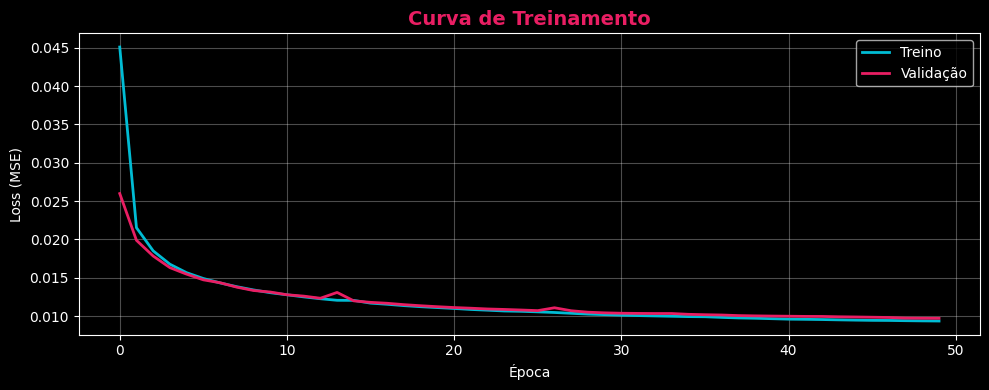

In [7]:
# ═══════════════════════════════════════════════════════════
# Curva de treinamento
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], label='Treino', color='#00BCD4', linewidth=2)
ax.plot(history.history['val_loss'], label='Validação', color='#E91E63', linewidth=2)
ax.set_xlabel('Época')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Curva de Treinamento', fontsize=14, fontweight='bold', color='#E91E63')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Comparar: Original vs Reconstruída

Vamos verificar visualmente a qualidade da reconstrução.


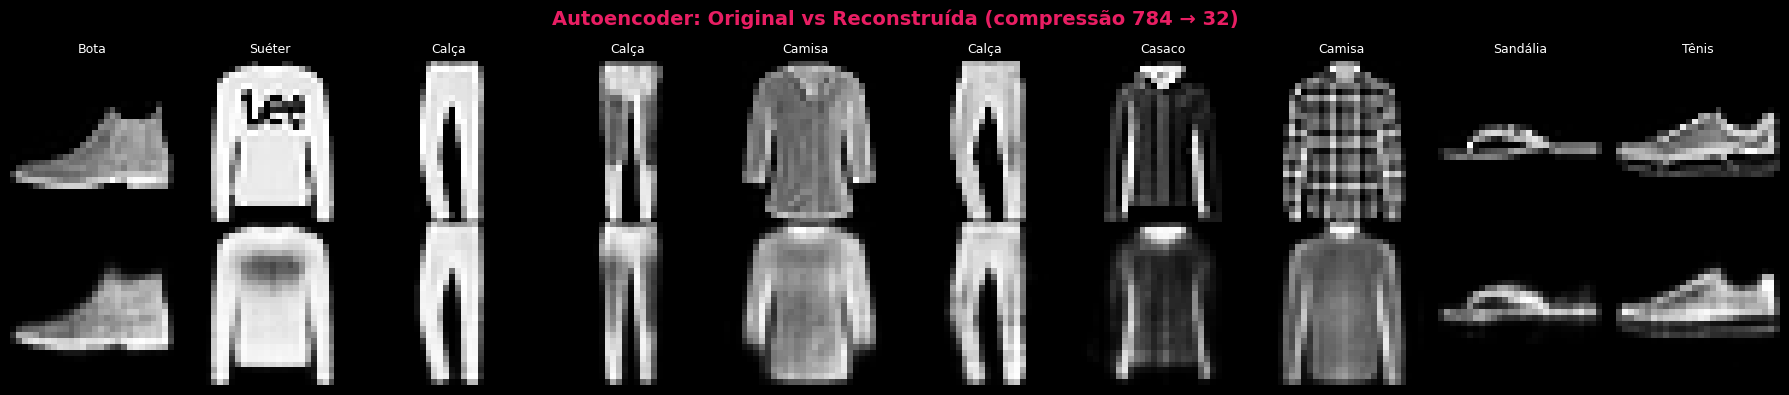

In [8]:
# ═══════════════════════════════════════════════════════════
# Reconstruir imagens do teste
# ═══════════════════════════════════════════════════════════

X_test_recon = autoencoder.predict(X_test_flat, verbose=0)

# Visualizar 10 imagens: original (cima) vs reconstruída (baixo)
n = 10
fig, axes = plt.subplots(2, n, figsize=(18, 4))

for i in range(n):
    # Original
    axes[0, i].imshow(X_test_flat[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(class_names[y_test[i]], fontsize=9)
    axes[0, i].axis('off')

    # Reconstruída
    axes[1, i].imshow(X_test_recon[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12, fontweight='bold', color='#00BCD4')
axes[1, 0].set_ylabel('Reconstruída', fontsize=12, fontweight='bold', color='#E91E63')

plt.suptitle('Autoencoder: Original vs Reconstruída (compressão 784 → 32)',
             fontsize=14, fontweight='bold', color='#E91E63')
plt.tight_layout()
plt.show()


## 6. Visualizar o Latent Space

O latent space é a **representação comprimida** das imagens (32 dimensões).

Para visualizar, vamos extrair os encodings e usar as 2 primeiras dimensões.

> **Insight:** Se itens similares ficam próximos no latent space, o autoencoder aprendeu features significativas!


In [9]:
# ═══════════════════════════════════════════════════════════
# Extrair representações do latent space (encoder)
# ═══════════════════════════════════════════════════════════

# Usar o encoder para obter representações comprimidas
latent_representations = encoder.predict(X_test_flat, verbose=0)

print(f"Shape original:    {X_test_flat.shape}")   # (10000, 784)
print(f"Shape latent:      {latent_representations.shape}")  # (10000, 32)
print(f"Compressão:        {784/latent_dim:.1f}x")


Shape original:    (10000, 784)
Shape latent:      (10000, 32)
Compressão:        24.5x


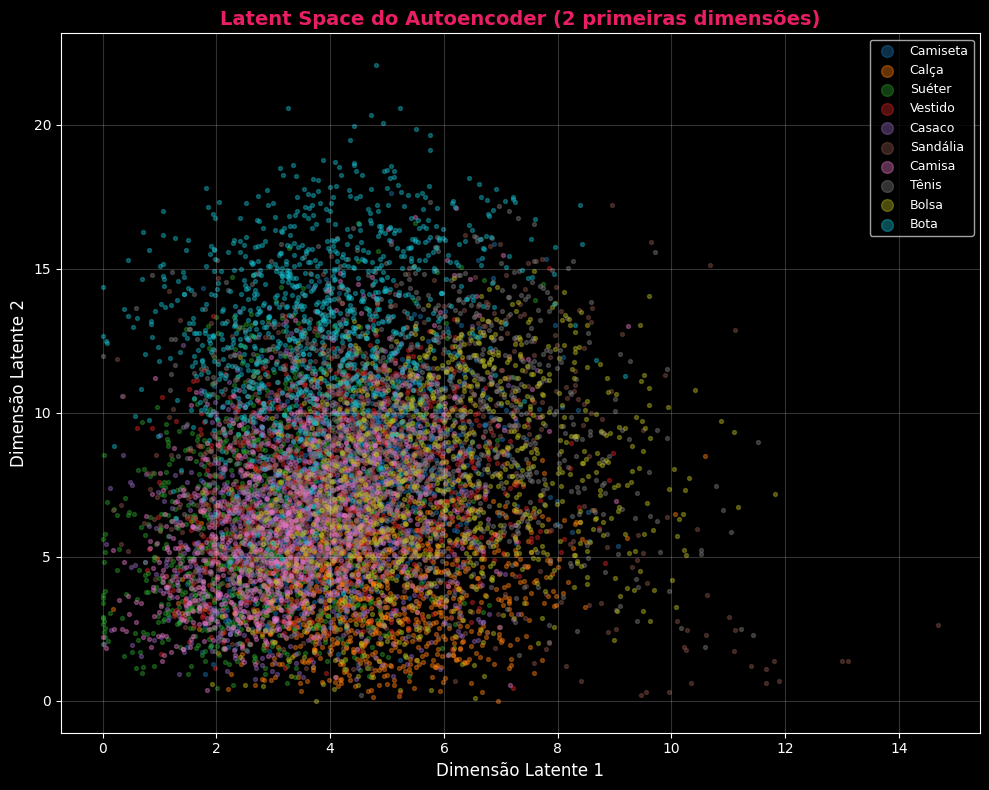

In [10]:
# ═══════════════════════════════════════════════════════════
# Scatter plot das 2 primeiras dimensões do latent space
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for i in range(10):
    mask = y_test == i
    ax.scatter(latent_representations[mask, 0],
               latent_representations[mask, 1],
               c=[colors[i]], label=class_names[i],
               alpha=0.4, s=8)

ax.set_xlabel('Dimensão Latente 1', fontsize=12)
ax.set_ylabel('Dimensão Latente 2', fontsize=12)
ax.set_title('Latent Space do Autoencoder (2 primeiras dimensões)',
             fontsize=14, fontweight='bold', color='#E91E63')
ax.legend(fontsize=9, markerscale=3, loc='best')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 7. Denoising Autoencoder

### Conceito

O **Denoising Autoencoder** recebe dados com **ruído** e aprende a reconstruir a versão **limpa**.

```
Imagem COM ruído → Autoencoder → Imagem SEM ruído
```

### Aplicação no negócio:
- Fotos de produtos tiradas com câmera ruim
- Imagens corrompidas durante upload
- Pré-processamento para OCR / reconhecimento

### Como implementar:
1. Adicionar **ruído gaussiano** às imagens de treino
2. Treinar: entrada = imagem com ruído, saída = imagem limpa


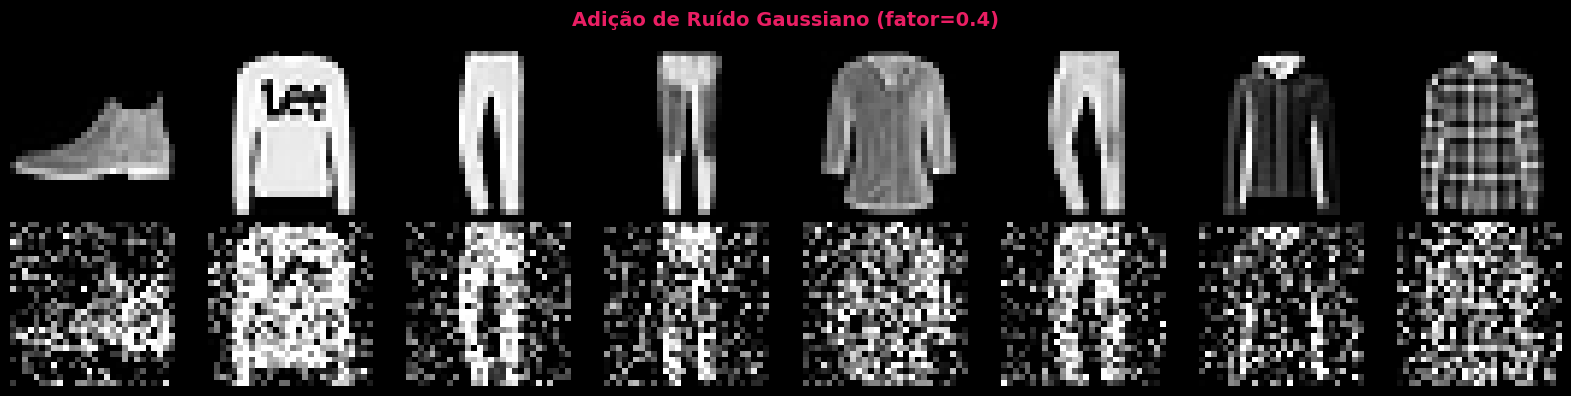

In [11]:
# ═══════════════════════════════════════════════════════════
# Adicionar ruído gaussiano às imagens
# ═══════════════════════════════════════════════════════════

noise_factor = 0.4

X_train_noisy = X_train_flat + noise_factor * np.random.normal(0, 1, X_train_flat.shape)
X_test_noisy  = X_test_flat  + noise_factor * np.random.normal(0, 1, X_test_flat.shape)

# Clipar para manter no range [0, 1]
X_train_noisy = np.clip(X_train_noisy, 0.0, 1.0)
X_test_noisy  = np.clip(X_test_noisy, 0.0, 1.0)

# Visualizar antes e depois do ruído
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(X_test_flat[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11, fontweight='bold', color='#00BCD4')
axes[1, 0].set_ylabel('Com Ruído', fontsize=11, fontweight='bold', color='#E91E63')
plt.suptitle(f'Adição de Ruído Gaussiano (fator={noise_factor})',
             fontsize=14, fontweight='bold', color='#E91E63')
plt.tight_layout()
plt.show()


In [12]:
# ═══════════════════════════════════════════════════════════
# Construir e treinar o Denoising Autoencoder
# ═══════════════════════════════════════════════════════════

# Mesma arquitetura
input_img_dn = Input(shape=(784,))
enc_dn = Dense(256, activation='relu')(input_img_dn)
enc_dn = Dense(64, activation='relu')(enc_dn)
enc_dn = Dense(32, activation='relu')(enc_dn)
dec_dn = Dense(64, activation='relu')(enc_dn)
dec_dn = Dense(256, activation='relu')(dec_dn)
dec_dn = Dense(784, activation='sigmoid')(dec_dn)

denoiser = Model(inputs=input_img_dn, outputs=dec_dn)
denoiser.compile(optimizer='adam', loss='mse')

# Treinar: entrada = com ruído, saída = limpa!
early_stop_dn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_dn = denoiser.fit(
    X_train_noisy,       # entrada COM ruído
    X_train_flat,        # saída esperada LIMPA
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop_dn],
    verbose=1
)

print(f"\nTreinamento finalizado na época {len(history_dn.history['loss'])}")


Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0518 - val_loss: 0.0308
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0268 - val_loss: 0.0245
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0231 - val_loss: 0.0224
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0215 - val_loss: 0.0210
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0204 - val_loss: 0.0206
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0197 - val_loss: 0.0195
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0190 - val_loss: 0.0190
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0184 - val_loss: 0.0186
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0180 - val_loss: 0.0183
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0176 - val_loss: 0.0180
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0174 - val_loss: 0.0184
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 

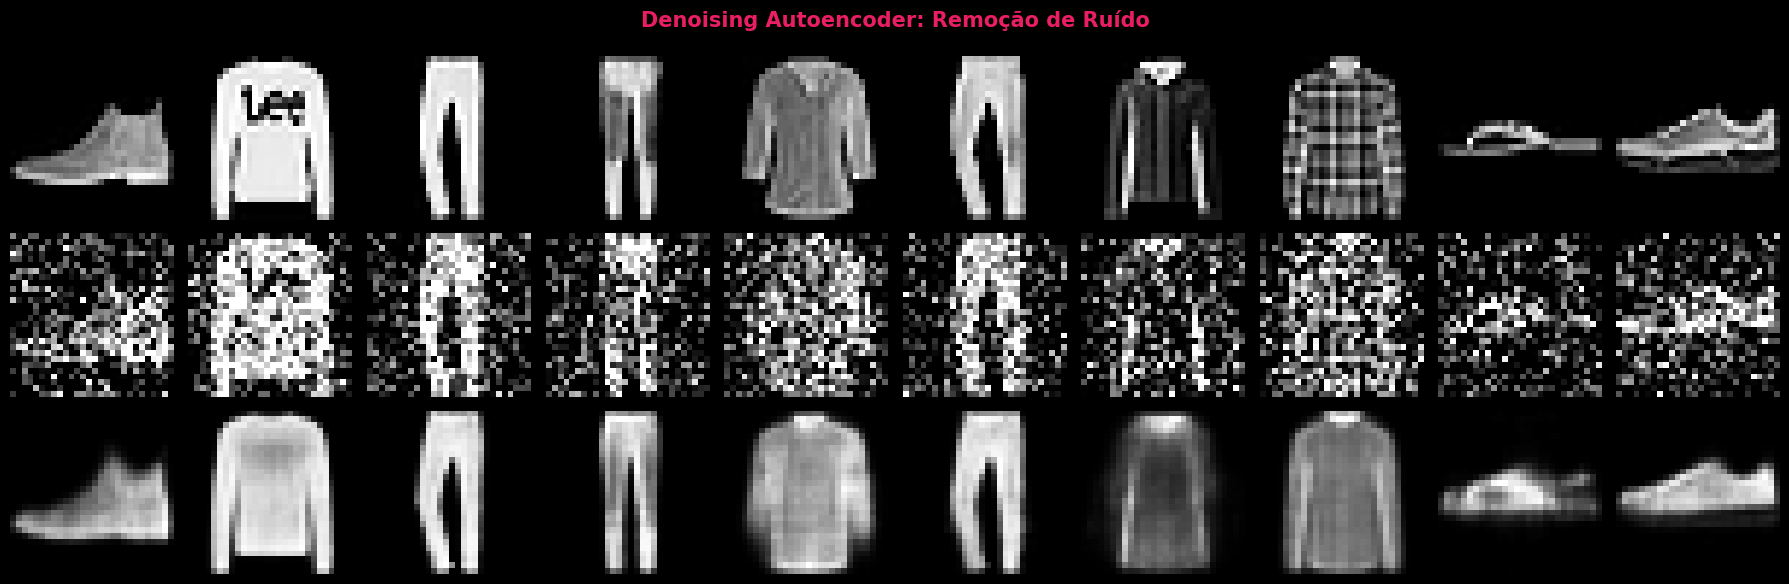

In [13]:
# ═══════════════════════════════════════════════════════════
# Comparar: Original → Com Ruído → Reconstruída (limpa)
# ═══════════════════════════════════════════════════════════

X_test_denoised = denoiser.predict(X_test_noisy, verbose=0)

n = 10
fig, axes = plt.subplots(3, n, figsize=(18, 6))

for i in range(n):
    axes[0, i].imshow(X_test_flat[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(X_test_denoised[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11, fontweight='bold', color='#00BCD4')
axes[1, 0].set_ylabel('Com Ruído', fontsize=11, fontweight='bold', color='#FF9800')
axes[2, 0].set_ylabel('Reconstruída', fontsize=11, fontweight='bold', color='#4CAF50')

plt.suptitle('Denoising Autoencoder: Remoção de Ruído',
             fontsize=15, fontweight='bold', color='#E91E63')
plt.tight_layout()
plt.show()


## 8. Conclusão

### Resumo dos dois modelos:

| Modelo | Entrada | Saída | Aplicação |
|--------|---------|-------|-----------|
| **Autoencoder** (compressão) | Imagem limpa | Imagem reconstruída | Compressão, feature extraction |
| **Denoising Autoencoder** | Imagem com ruído | Imagem limpa | Limpeza de imagens, pré-processamento |

### Insights para o MBA:
- **Compressão 24.5×** — armazenamento 96% menor com qualidade aceitável
- **Latent space** pode ser usado como feature vector para recomendação de produtos
- **Denoising** automatiza limpeza de fotos de sellers/fornecedores

### Próximo passo:
Aplicar autoencoders em **dados de texto** (Notebook 3).
